# Project Title: Build a Content-Based Movie Recommendation System

The rapid growth of data collection has led to a new era of information. Data is being used to create more efficient systems and this is where Recommendation Systems come into play. Recommendation Systems are a type of information filtering systems as they improve the quality of search results and provides items that are more relevant to the search item or are realted to the search history of the user.

They are used to predict the rating or preference that a user would give to an item. Almost every major tech company has applied them in some form or the other: Amazon uses it to suggest products to customers, YouTube uses it to decide which video to play next on autoplay, and Facebook uses it to recommend pages to like and people to follow. Moreover, companies like Netflix and Spotify depend highly on the effectiveness of their recommendation engines for their business and sucees.

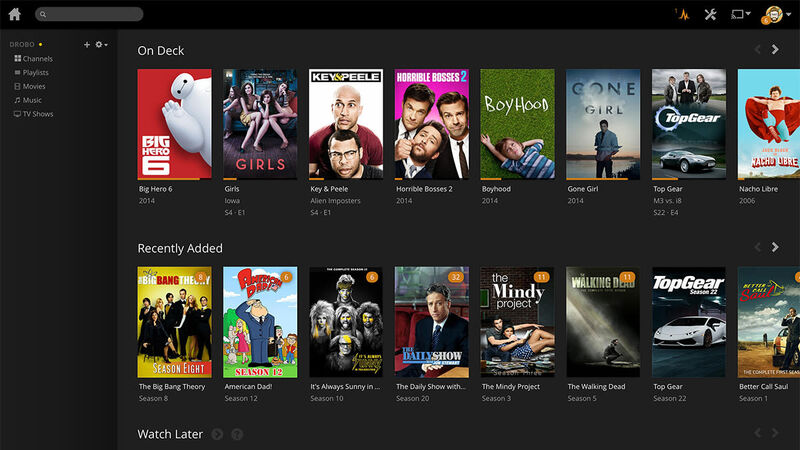

There are basically three types of recommender systems:-

* **Demographic Filtering**- They offer generalized recommendations to every user, based on movie popularity and/or genre. The System recommends the same movies to users with similar demographic features. Since each user is different , this approach is considered to be too simple. The basic idea behind this system is that movies that are more popular and critically acclaimed will have a higher probability of being liked by the average audience.


* **Content Based Filtering**- They suggest similar items based on a particular item. This system uses item metadata, such as genre, director, description, actors, etc. for movies, to make these recommendations. The general idea behind these recommender systems is that if a person liked a particular item, he or she will also like an item that is similar to it.


*  **Collaborative Filtering**- This system matches persons with similar interests and provides recommendations based on this matching. Collaborative filters do not require item metadata like its content-based counterparts.


In [24]:
import pandas as pd 
import numpy as np 
df1=pd.read_csv('C:/Users/Lenovo/Desktop/Inbox/tmdb_5000_movies/tmdb_5000_movies.csv')
df1.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


The First dataset has the following features:-

* budget - The budget in which the movie was made.
* genre - The genre of the movie, Action, Comedy ,Thriller etc.
* homepage - A link to the homepage of the movie.
* id - This is infact the movie_id as in the first dataset.
* keywords - The keywords or tags related to the movie.
* original_language - The language in which the movie was made.
* original_title - The title of the movie before translation or adaptation.
* overview - A brief description of the movie.
* popularity - A numeric quantity specifying the movie popularity.
* production_companies - The production house of the movie.
* production_countries - The country in which it was produced.
* release_date - The date on which it was released.
* revenue - The worldwide revenue generated by the movie.
* runtime - The running time of the movie in minutes.
* status - "Released" or "Rumored".
* tagline - Movie's tagline.
* title - Title of the movie.
* vote_average -  average ratings the movie recieved.
* vote_count - the count of votes recieved.

Let's join the two dataset on the 'id' column


In [25]:
df2=pd.read_csv('C:/Users/Lenovo/Desktop/Inbox/tmdb_5000_credits/tmdb_5000_credits.csv')
df2.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


The second dataset contains the following features:-

* movie_id - A unique identifier for each movie.
* cast - The name of lead and supporting actors.
* crew - The name of Director, Editor, Composer, Writer etc.


In [26]:
df2.columns = ['id','tittle','cast','crew']
df= df1.merge(df2,on='id')

In [27]:
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,tittle,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [29]:
#These columns (genres, keywords, cast) are stored as strings, so we convert them:
import ast
def convert(text):
    L = []
    for i in ast.literal_eval(text):
        L.append(i['name'])
    return L

df['genres'] = df['genres'].apply(convert)
df['keywords'] = df['keywords'].apply(convert)

In [30]:
#Extract top 3 actors from cast
def convert_cast(text):
    L = []
    counter = 0
    for i in ast.literal_eval(text):
        if counter < 3:
            L.append(i['name'])
            counter += 1
        else:
            break
    return L

df['cast'] = df['cast'].apply(convert_cast)

In [32]:
df['overview'] = df['overview'].fillna('').apply(lambda x: x.split())

In [33]:
def remove_space(L):
    return [i.replace(" ", "") for i in L]

df['genres'] = df['genres'].apply(remove_space)
df['keywords'] = df['keywords'].apply(remove_space)
df['cast'] = df['cast'].apply(remove_space)

In [34]:
df['tags'] = df['overview'] + df['genres'] + df['keywords'] + df['cast']

In [35]:
df['tags'] = df['tags'].apply(lambda x: " ".join(x))

In [36]:
#Convert to lowercase:
df['tags'] = df['tags'].apply(lambda x: x.lower())

In [39]:
#remove punctuation
import re

df['tags'] = df['tags'].apply(lambda x: re.sub(r'[^\w\s]', '', x.lower()))

2. Vectorization

• Use CountVectorizer or TfidfVectorizer

• Calculate cosine similarity matrix for all movies

In [40]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=5000, stop_words='english')
vectors = cv.fit_transform(df['tags']).toarray()

C:\Users\Lenovo\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


TfidfVectorizer

* Reduces weight of common words
* Highlights rare/unique words

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
vectors = tfidf.fit_transform(df['tags']).toarray()

In [42]:
CountVectorizer(max_features=5000, stop_words='english')

CountVectorizer(max_features=5000, stop_words='english')

* compute similarity:

In [43]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(vectors)

In [44]:
cv_vectors = CountVectorizer(max_features=5000, stop_words='english').fit_transform(df['tags'])
tfidf_vectors = TfidfVectorizer(max_features=5000, stop_words='english').fit_transform(df['tags'])

In [45]:
cv_vectors

<4803x5000 sparse matrix of type '<class 'numpy.int64'>'
	with 129525 stored elements in Compressed Sparse Row format>

In [46]:
tfidf_vectors

<4803x5000 sparse matrix of type '<class 'numpy.float64'>'
	with 129525 stored elements in Compressed Sparse Row format>

In [47]:
def recommend(title):
    # Check if movie exists
    if title not in df['title'].values:
        return "Movie not found in dataset"
    
    # Get index of the movie
    movie_index = df[df['title'] == title].index[0]
    
    # Get similarity scores (distance from all movies)
    distances = similarity[movie_index]
    
    # Sort movies based on similarity score
    movies_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])
    
    # Get top 5 similar movies (excluding itself)
    recommended_movies = []
    for i in movies_list[1:6]:
        recommended_movies.append(df.iloc[i[0]].title)
    
    return recommended_movies

In [48]:
recommend("Avatar")

['Apollo 18', 'Aliens', 'Star Trek Into Darkness', 'Titan A.E.', 'Predators']

In [49]:
def recommend(title):
    movie_index = df[df['title'] == title].index[0]
    distances = similarity[movie_index]
    
    movies_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])
    
    for i in movies_list[1:6]:
        print(df.iloc[i[0]].title, ":", i[1])

In [50]:
pip install streamlit requests

In [51]:
import pickle

pickle.dump(df, open('movies.pkl', 'wb'))
pickle.dump(similarity, open('similarity.pkl', 'wb'))

In [52]:
import streamlit as st
import pickle
import requests

# Load data
movies = pickle.load(open('movies.pkl', 'rb'))
similarity = pickle.load(open('similarity.pkl', 'rb'))

# Fetch poster from TMDB
def fetch_poster(movie_id):
    api_key = "YOUR_API_KEY_HERE"
    url = f"https://api.themoviedb.org/3/movie/{movie_id}?api_key={api_key}"
    data = requests.get(url).json()
    poster_path = data.get('poster_path')
    return "https://image.tmdb.org/t/p/w500/" + poster_path if poster_path else ""

# Recommendation function
def recommend(movie):
    movie_index = movies[movies['title'] == movie].index[0]
    distances = similarity[movie_index]
    movies_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]

    recommended_movies = []
    recommended_posters = []

    for i in movies_list:
        movie_id = movies.iloc[i[0]].movie_id
        recommended_movies.append(movies.iloc[i[0]].title)
        recommended_posters.append(fetch_poster(movie_id))

    return recommended_movies, recommended_posters

# UI
st.title("🎬 Movie Recommender System")

selected_movie = st.selectbox(
    "Type or select a movie",
    movies['title'].values
)

if st.button("Recommend"):
    names, posters = recommend(selected_movie)

    col1, col2, col3, col4, col5 = st.columns(5)

    for i, col in enumerate([col1, col2, col3, col4, col5]):
        with col:
            st.text(names[i])
            st.image(posters[i])

2026-04-20 23:20:39.934 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 23:20:41.598 
  command:

    streamlit run C:\Users\Lenovo\anaconda3\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-20 23:20:41.600 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 23:20:41.603 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 23:20:41.640 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 23:20:41.641 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 23:20:41.702 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 23:20:41.711 Thread 'MainThread': m